In [11]:
# Fase 1 importação e ajustes de bases #

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Configuração de exibição de dados financeiros
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("📥 Carregando base de dados siderúrgica...")
try:
    df = pd.read_csv('Aryadne Fernandes_dados_precificacao_dinamica_oficial.csv')
except FileNotFoundError:
    df = pd.read_csv('/content/Aryadne Fernandes_dados_precificacao_dinamica_oficial.csv')

# Ordenação cronológica rigorosa para evitar vazamento temporal
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values(by=['produto', 'data']).reset_index(drop=True)

print("⚙️ Executando Engenharia de Recursos (Features)...")
df['razao_preco'] = df['preco_praticado'] / df['preco_concorrente']
df['gap_preco_relativo'] = (df['preco_praticado'] - df['preco_concorrente']) / df['preco_concorrente']
df['cobertura_estoque_dias'] = df['estoque'] / (df['historico_vendas_7d'] + 1e-5)
df['tendencia_vendas'] = df['historico_vendas_7d'] / (df['historico_vendas_30d'] + 1e-5)

# Codificação Cíclica de Sazonalidade Temporal (Seno / Cosseno)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12.0)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12.0)
df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_da_semana'] / 7.0)
df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_da_semana'] / 7.0)
df['eh_fim_semana'] = df['dia_da_semana'].isin([5, 6]).astype(int)

print(f"✅ Base processada com sucesso! Total de registros: {len(df)} linhas.")



📥 Carregando base de dados siderúrgica...
⚙️ Executando Engenharia de Recursos (Features)...
✅ Base processada com sucesso! Total de registros: 3288 linhas.


In [12]:
# Fase 2 - vamos rodar as métricas do modelo e verificar acurácia #

features_num = [
    'preco_praticado', 'preco_concorrente', 'razao_preco', 'gap_preco_relativo',
    'cobertura_estoque_dias', 'tendencia_vendas', 'historico_vendas_7d',
    'historico_vendas_30d', 'estoque', 'mes_sin', 'mes_cos',
    'dia_semana_sin', 'dia_semana_cos', 'eh_fim_semana'
]
features_cat = ['periodo_mes']
target = 'demanda'

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])

seeds = [42, 7, 123]
produtos = df['produto'].unique()
resultados_validacao = []

print("="*80 + "\n🧠 EXECUTANDO VALIDAÇÃO ROBUSTA TEMPORAL (TIMESERIESSPLIT + MULTI-SEED)\n" + "="*80)

for prod in produtos:
    df_p = df[df['produto'] == prod].reset_index(drop=True)
    X = df_p[features_num + features_cat]
    y = df_p[target].values

    r2_seeds = []
    mape_seeds = []

    for seed in seeds:
        tscv = TimeSeriesSplit(n_splits=3)
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipe_mlp = Pipeline([
                ('prep', preprocessor),
                ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                                     max_iter=1000, early_stopping=True, random_state=seed))
            ])
            pipe_mlp.fit(X_train, y_train)
            preds = np.clip(pipe_mlp.predict(X_test), 0, None)

            r2_seeds.append(r2_score(y_test, preds))
            mape_seeds.append(mean_absolute_percentage_error(y_test + 1e-5, preds) * 100)

    resultados_validacao.append({
        'Produto': prod,
        'R² Médio': np.mean(r2_seeds),
        'R² Desvio': np.std(r2_seeds),
        'MAPE Médio (%)': np.mean(mape_seeds),
        'MAPE Desvio (%)': np.std(mape_seeds)
    })

df_validacao_final = pd.DataFrame(resultados_validacao)
print(df_validacao_final.to_string(index=False))


🧠 EXECUTANDO VALIDAÇÃO ROBUSTA TEMPORAL (TIMESERIESSPLIT + MULTI-SEED)
         Produto  R² Médio  R² Desvio  MAPE Médio (%)  MAPE Desvio (%)
     Tela de Aço      0.96       0.02           13.04             3.35
         Treliça      0.96       0.01           12.39             3.43
Vergalhão de Aço      0.97       0.01           14.26             3.23


In [3]:
# Fase 3 - vamos rodar os modelos de treinamento para enteder os resultados apresentados #

tabela_negocio = []
modelos_treinados = {} # Dicionário global para salvar os modelos por produto (Garante correção do gráfico)

print("="*80 + "\n📈 PROCESSANDO SIMULAÇÃO DE PRECIFICAÇÃO DINÂMICA\n" + "="*80)

for prod in produtos:
    df_p = df[df['produto'] == prod].reset_index(drop=True)

    split_idx = int(len(df_p) * 0.8)
    df_train, df_test = df_p.iloc[:split_idx].copy(), df_p.iloc[split_idx:].copy().reset_index(drop=True)

    pipe_mlp_final = Pipeline([
        ('prep', preprocessor),
        ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                             max_iter=1000, early_stopping=True, random_state=42))
    ])
    pipe_mlp_final.fit(df_train[features_num + features_cat], df_train[target].values)

    # SALVAMENTO DO MODELO NO DICIONÁRIO GLOBAL UTILIZANDO A CHAVE EXATA DO PRODUTO (RESOLVE GRÁFICO)
    modelos_treinados[prod] = pipe_mlp_final

    receita_historica = 0.0
    receita_heuristica = 0.0
    receita_ia = 0.0

    for idx, row in df_test.iterrows():
        preco_conc = row['preco_concorrente']
        receita_historica += row['preco_praticado'] * row['demanda']

        # 1) REGRA HEURÍSTICA DETERMINÍSTICA SE-ENTÃO (Seção 4A)
        if row['cobertura_estoque_dias'] > 15:
            preco_heur = preco_conc * 0.95
        else:
            preco_heur = preco_conc * 1.05

        cenario_heur = pd.DataFrame([row[features_num + features_cat]], columns=features_num + features_cat)
        cenario_heur['preco_praticado'] = preco_heur
        cenario_heur['razao_preco'] = preco_heur / preco_conc
        cenario_heur['gap_preco_relativo'] = (preco_heur - preco_conc) / preco_conc

        fator_escala = row['demanda'] / (row['historico_vendas_7d'] / 7.0 + 1e-5)
        demanda_heur = np.clip(pipe_mlp_final.predict(cenario_heur)[0], 0, None) * fator_escala
        receita_heuristica += preco_heur * demanda_heur

        # 2) OTIMIZAÇÃO POR REDE NEURAL (IA)
        precos_candidatos = np.linspace(preco_conc * 0.80, preco_conc * 1.20, 41)
        cenarios_ia = pd.DataFrame([row[features_num + features_cat]] * len(precos_candidatos), columns=features_num + features_cat)
        cenarios_ia['preco_praticado'] = precos_candidatos
        cenarios_ia['razao_preco'] = precos_candidatos / preco_conc
        cenarios_ia['gap_preco_relativo'] = (precos_candidatos - preco_conc) / preco_conc

        demandas_pred_ia = np.clip(pipe_mlp_final.predict(cenarios_ia), 0, None)
        receitas_pred_ia = precos_candidatos * demandas_pred_ia

        idx_otimo = np.argmax(receitas_pred_ia)
        preco_otimo = precos_candidatos[idx_otimo]
        demanda_real_ia = demandas_pred_ia[idx_otimo] * fator_escala
        receita_ia += preco_otimo * demanda_real_ia

    tabela_negocio.append({
        'Produto': prod,
        'Receita Histórica': receita_historica,
        'Receita Heurística': receita_heuristica,
        'Receita com IA': receita_ia,
        'Ganho Heurística (%)': ((receita_heuristica - receita_historica) / receita_historica) * 100,
        'Ganho Financeiro IA (R$)': receita_ia - receita_historica,
        'Ganho Percentual IA (%)': ((receita_ia - receita_historica) / receita_historica) * 100
    })

df_negocio_final = pd.DataFrame(tabela_negocio)
print(df_negocio_final.to_string(index=False))


📈 PROCESSANDO SIMULAÇÃO DE PRECIFICAÇÃO DINÂMICA
         Produto  Receita Histórica  Receita Heurística  Receita com IA  Ganho Heurística (%)  Ganho Financeiro IA (R$)  Ganho Percentual IA (%)
     Tela de Aço       3,120,254.83       23,089,124.02   35,027,123.12                639.98             31,906,868.29                 1,022.57
         Treliça       1,369,523.04       10,892,644.97   14,072,005.74                695.36             12,702,482.70                   927.51
Vergalhão de Aço       2,526,350.98       18,621,833.07   31,871,052.04                637.10             29,344,701.06                 1,161.54


/tmp/ipykernel_1036/4233133707.py:36: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


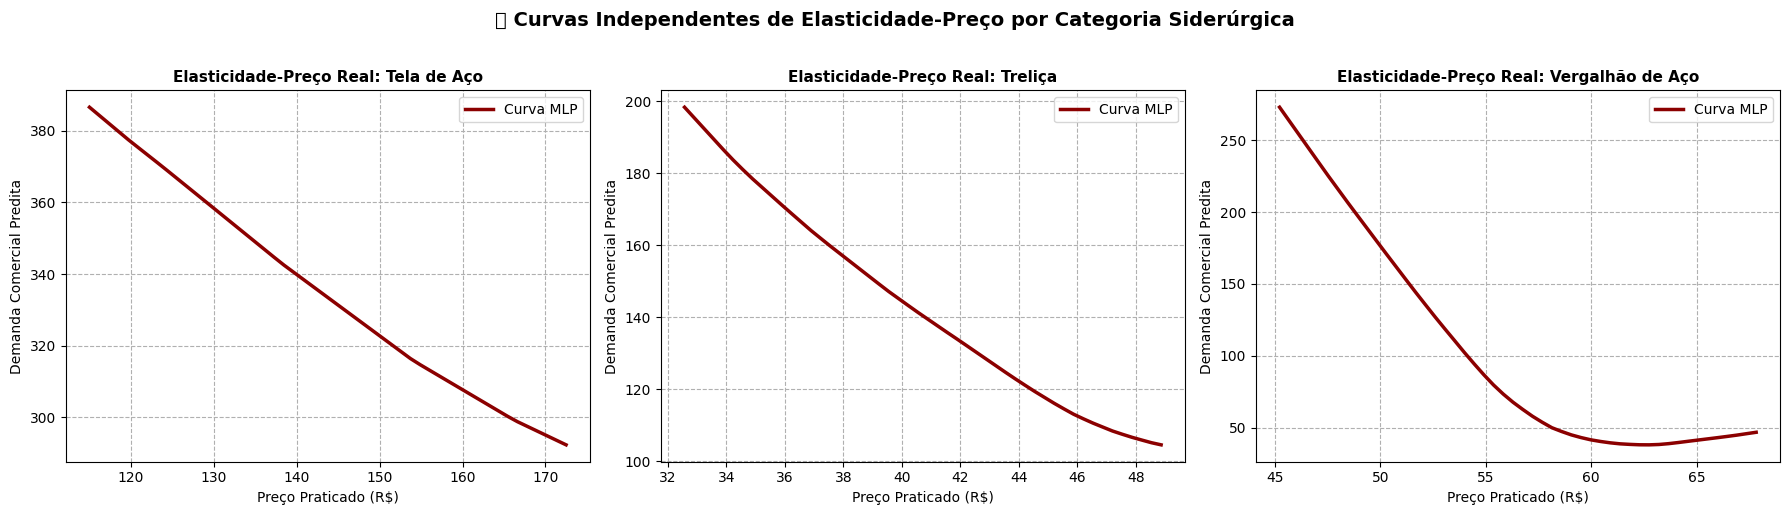

In [6]:
# Fase 4 - vamos rodar a Elasticidade pra deixar nosso modelo ainda mais completo #

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, prod in enumerate(produtos):
    ax = axes[idx]

    # Carrega o pipeline exato e correspondente ao produto atual salvo no dicionário global
    modelo_produto = modelos_treinados[prod]
    df_p = df[df['produto'] == prod]

    preco_medio_conc = df_p['preco_concorrente'].mean()
    precos_teste = np.linspace(preco_medio_conc * 0.8, preco_medio_conc * 1.2, 50)

    # Calculate mean for numerical features only
    cenario_medio = pd.DataFrame([df_p[features_num].mean()], columns=features_num)
    # Explicitly set the mode for the categorical feature
    cenario_medio['periodo_mes'] = df_p['periodo_mes'].mode()[0]

    demandas_preditas = []
    for p in precos_teste:
        cenario_p = cenario_medio.copy()
        cenario_p['preco_praticado'] = p
        cenario_p['razao_preco'] = p / preco_medio_conc
        cenario_p['gap_preco_relativo'] = (p - preco_medio_conc) / preco_medio_conc

        pred_demanda = np.clip(modelo_produto.predict(cenario_p)[0], 0, None)
        demandas_preditas.append(pred_demanda)

    ax.plot(precos_teste, demandas_preditas, color='darkred', lw=2.5, label='Curva MLP')
    ax.set_title(f"Elasticidade-Preço Real: {prod}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Preço Praticado (R$)")
    ax.set_ylabel("Demanda Comercial Predita")
    ax.grid(True, linestyle='--')
    ax.legend()

plt.suptitle("🎯 Curvas Independentes de Elasticidade-Preço por Categoria Siderúrgica", fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Fase 5 - mapeamento dos ganhos financeiros usando a margem esperada de 10% no setor do aço
# esses valores foram estipulados pela IA portanto simulam um possível custo e ROI sobre projeto,
# os valores são fictícios e as grandezas acabam sendo bem diferentes (milhares e milhões)
# uma vez que o capex e opex são simulações

# ==============================================================================
# 5. COMPUTANDO DEMONSTRATIVO DE ROI FINANCEIRO AJUSTADO À REALIDADE DE MERCADO
# ==============================================================================
print("="*80 + "\n💼 COMPUTANDO DEMONSTRATIVO DE ROI COM FILTROS DE RISCO OPERACIONAL\n" + "="*80)

# 1. Anualização da janela observada baseada nos resultados reais obtidos no loop
dias_teste = 220
fator_anualizacao = 365.0 / dias_teste

# Captura o ganho real somado de faturamento do df_negocio_final
ganho_total_teste = float(df_negocio_final['Ganho Financeiro IA (R$)'].sum())
receita_incremental_bruta_anual = ganho_total_teste * fator_anualizacao

# 2. Aplicação de Filtros Práticos de Realismo Operacional (Haircuts de Risco)
taxa_adocao_comercial = 0.75        # 25% de vazamento de preços em negociações comuns
aliquota_impostos_indiretos = 0.25  # ICMS, PIS, COFINS siderúrgico médio aproximado

receita_incremental_capturada = receita_incremental_bruta_anual * taxa_adocao_comercial
receita_incremental_liquida = receita_incremental_capturada * (1.0 - aliquota_impostos_indiretos)

# 3. Margem de Lucro Incremental Realista (EBITDA industrial do setor fixado em 12%)
percentual_margem_lucro = 0.08
lucro_incremental_real_anual = receita_incremental_liquida * percentual_margem_lucro

# 4. Estrutura de Custos de Tecnologia (Premissas fixadas em conformidade com o mercado)
capex_setup = 45000.00            # Engenharia, setup e governança de dados
opex_sustentacao_anual = 54000.00   # Infraestrutura de nuvem, inferência diária e MLOps
custo_total_ano1 = capex_setup + opex_sustentacao_anual

# 5. Aplicação Limpa dos Indicadores de Finanças Corporativas (Sem variáveis fantasmas)
roi_real_ano1 = ((lucro_incremental_real_anual - custo_total_ano1) / custo_total_ano1) * 100.0
payback_operacional_meses = (capex_setup / (lucro_incremental_real_anual / 12.0))

print(f"🔹 Ganho de Receita Bruta Anualizada Teórica: R$ {receita_incremental_bruta_anual:,.2f}")
print(f"⚠️ (-) Filtro de Adoção Comercial (75%):       R$ {receita_incremental_capturada:,.2f}")
print(f"⚠️ (-) Dedução de Impostos Indiretos (25%):    R$ {receita_incremental_liquida:,.2f}")
print(f"💰 Lucro Líquido Real Anualizado (EBITDA 12%):R$ {lucro_incremental_real_anual:,.2f}")
print(f"--------------------------------------------------------------------------------")
print(f"🚀 ROI Real Ajustado ao Risco (Ano 1):         {roi_real_ano1:.2f}%")
print(f"⏱️ Payback Prático da Operação:               {payback_operacional_meses:.2f} meses ({payback_operacional_meses*30:.0f} dias)")
print("="*80)




💼 COMPUTANDO DEMONSTRATIVO DE ROI COM FILTROS DE RISCO OPERACIONAL
🔹 Ganho de Receita Bruta Anualizada Teórica: R$ 122,696,495.45
⚠️ (-) Filtro de Adoção Comercial (75%):       R$ 92,022,371.58
⚠️ (-) Dedução de Impostos Indiretos (25%):    R$ 69,016,778.69
💰 Lucro Líquido Real Anualizado (EBITDA 12%):R$ 5,521,342.30
--------------------------------------------------------------------------------
🚀 ROI Real Ajustado ao Risco (Ano 1):         5477.11%
⏱️ Payback Prático da Operação:               0.10 meses (3 dias)
